In [30]:
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime

from sklearn.model_selection import train_test_split
from sklearn.utils import shuffle

This is the classic SMS Spam Collection dataset: a set of labeled text messages, some legitimate ("ham") and some spam, covering all kinds of everyday topics -- health, weather and so forth.

In [31]:
# Unfortunately this URL doesn't work directly with pd.read_csv
!wget -nc https://lazyprogrammer.me/course_files/spam.csv

File ‘spam.csv’ already there; not retrieving.



In [32]:
#bad formatting!
!head spam.csv

v1,v2,,,
ham,"Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...",,,
ham,Ok lar... Joking wif u oni...,,,
spam,Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std txt rate)T&C's apply 08452810075over18's,,,
ham,U dun say so early hor... U c already then say...,,,
ham,"Nah I don't think he goes to usf, he lives around here though",,,
spam,"FreeMsg Hey there darling it's been 3 week's now and no word back! I'd like some fun you up for it still? Tb ok! XxX std chgs to send, �1.50 to rcv",,,
ham,Even my brother is not like to speak with me. They treat me like aids patent.,,,
ham,As per your request 'Melle Melle (Oru Minnaminunginte Nurungu Vettam)' has been set as your callertune for all Callers. Press *9 to copy your friends Callertune,,,
spam,WINNER!! As a valued network customer you have been selected to receivea �900 prize reward! To claim call 09061701461. Claim 

In [33]:
df = pd.read_csv('spam.csv', encoding='ISO-8859-1')

In [34]:
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [35]:
# drop unnecessary columns
df = df.drop(["Unnamed: 2", "Unnamed: 3", "Unnamed: 4"], axis=1)

In [36]:
df.head()

,v1,v2
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [37]:
# rename columns to something better
df.columns = ['labels', 'data']

In [38]:
df.head()

,labels,data
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [39]:
# create binary labels
df['b_labels'] = df['labels'].map({'ham': 0, 'spam': 1})

Note: normally you'd want to use something like sklearn's LabelEncoder to automatically map string columns to be integers from zero up to K minus one, but let's keep it simple!

In [40]:
df_train, df_test = train_test_split(df, test_size=0.33)

In [41]:
df_train.shape, df_test.shape

((3733, 3), (1839, 3))

In [42]:
# 0 = padding
idx = 1
word2idx = {'<PAD>': 0}

In [43]:
# you could always use gensim or spacy for tokenization,
# but let's keep it simple!
for i, row in df_train.iterrows():
  tokens = row['data'].lower().split() # simple tokenization
  for token in tokens:
    if token not in word2idx:
      word2idx[token] = idx
      idx += 1

In [44]:
word2idx

{'<PAD>': 0,
 'nah': 1,
 "it's": 2,
 'straight,': 3,
 'if': 4,
 'you': 5,
 'can': 6,
 'just': 7,
 'bring': 8,
 'bud': 9,
 'or': 10,
 'drinks': 11,
 'something': 12,
 "that's": 13,
 'actually': 14,
 'a': 15,
 'little': 16,
 'more': 17,
 'useful': 18,
 'than': 19,
 'straight': 20,
 'cash': 21,
 'how': 22,
 'many': 23,
 'licks': 24,
 'does': 25,
 'it': 26,
 'take': 27,
 'to': 28,
 'get': 29,
 'the': 30,
 'center': 31,
 'of': 32,
 'tootsie': 33,
 'pop?': 34,
 'i': 35,
 "don't": 36,
 'think': 37,
 'he': 38,
 'has': 39,
 'spatula': 40,
 'hands!': 41,
 'why': 42,
 'dint': 43,
 'come': 44,
 'with': 45,
 'us.': 46,
 'mostly': 47,
 'sports': 48,
 'type..lyk': 49,
 'footbl,crckt..': 50,
 'even': 51,
 'cant': 52,
 'close': 53,
 'my': 54,
 'eyes': 55,
 'are': 56,
 'in': 57,
 'me': 58,
 'our': 59,
 'vava': 60,
 'playing': 61,
 'umma': 62,
 ':-d': 63,
 'bloomberg': 64,
 '-message': 65,
 '+447797706009': 66,
 'wait?': 67,
 'apply': 68,
 'for': 69,
 'your': 70,
 'future': 71,
 'http://careers.': 72,
 '

In [45]:
len(word2idx)

10547

In [46]:
# convert data into word indices
# note: could have done this on the fly earlier
train_sentences_as_int = []
for i, row in df_train.iterrows():
  tokens = row['data'].lower().split()
  sentence_as_int = [word2idx[token] for token in tokens]
  train_sentences_as_int.append(sentence_as_int)

In [47]:
test_sentences_as_int = []
for i, row in df_test.iterrows():
  tokens = row['data'].lower().split()
  sentence_as_int = [word2idx[token] for token in tokens if token in word2idx]
  test_sentences_as_int.append(sentence_as_int)

In [48]:
len(train_sentences_as_int), len(test_sentences_as_int)

(3733, 1839)

In [49]:
def data_generator(X, y, batch_size=32):
  X, y = shuffle(X, y)
  n_batches = int(np.ceil(len(y) / batch_size))
  for i in range(n_batches):
    end = min((i + 1) * batch_size, len(y))

    X_batch = X[i * batch_size:end]
    y_batch = y[i * batch_size:end]

    # pad X_batch to be N x T
    max_len = np.max([len(x) for x in X_batch])
    for j in range(len(X_batch)):
      x = X_batch[j]
      pad = [0] * (max_len - len(x))
      X_batch[j] = pad + x

    # convert to tensor
    X_batch = torch.from_numpy(np.array(X_batch)).long()
    y_batch = torch.from_numpy(np.array(y_batch)).long()

    yield X_batch, y_batch

In [50]:
train_gen = lambda: data_generator(train_sentences_as_int, df_train.b_labels)
test_gen = lambda: data_generator(test_sentences_as_int, df_test.b_labels)

**Note:** Before this training loop can run, we need the model itself, its device, loss, and optimizer defined -- those cells weren't visible in the supplied screenshots. The cells below define an RNN classifier matching the shape this notebook's data generator produces (`N x T` integer batches, binary labels), using `device = mps` (Apple GPU) with `cuda`/`cpu` fallback, following the same pattern as the other notebooks in this course. Replace/extend these if your original notebook defines the model differently.

In [51]:
device = torch.device("mps" if torch.backends.mps.is_available() else ("cuda:0" if torch.cuda.is_available() else "cpu"))
print(device)

mps


In [52]:
class RNN(nn.Module):
  def __init__(self, n_vocab, embed_dim, n_hidden, n_rnnlayers, n_outputs):
    super(RNN, self).__init__()
    self.V = n_vocab
    self.D = embed_dim
    self.M = n_hidden
    self.K = n_outputs
    self.L = n_rnnlayers

    self.embed = nn.Embedding(self.V, self.D)
    self.rnn = nn.LSTM(
        input_size=self.D,
        hidden_size=self.M,
        num_layers=self.L,
        batch_first=True)
    self.fc = nn.Linear(self.M, self.K)

  def forward(self, X):
    h0 = torch.zeros(self.L, X.size(0), self.M).to(device)
    c0 = torch.zeros(self.L, X.size(0), self.M).to(device)

    out = self.embed(X)
    out, _ = self.rnn(out, (h0, c0))

    out = self.fc(out[:, -1, :])
    return out

In [53]:
model = RNN(len(word2idx), 20, 15, 1, 1)
model.to(device)

RNN(
  (embed): Embedding(10547, 20)
  (rnn): LSTM(20, 15, batch_first=True)
  (fc): Linear(in_features=15, out_features=1, bias=True)
)

In [54]:
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters())

In [55]:
# A function to encapsulate the training loop
def batch_gd(model, criterion, optimizer, epochs):
  train_losses = np.zeros(epochs)
  test_losses = np.zeros(epochs)

  for it in range(epochs):
    t0 = datetime.now()
    train_loss = []
    for inputs, targets in train_gen():
      # print("inputs.shape:", inputs.shape, "targets.shape:", targets.shape)
      targets = targets.view(-1, 1).float()
      # move data to GPU
      inputs, targets = inputs.to(device), targets.to(device)

      # zero the parameter gradients
      optimizer.zero_grad()

      # Forward pass
      outputs = model(inputs)
      loss = criterion(outputs, targets)

      # Backward and optimize
      loss.backward()
      optimizer.step()

      train_loss.append(loss.item())

    # Get train loss and test loss
    train_loss = np.mean(train_loss)

    test_loss = []
    for inputs, targets in test_gen():
      targets = targets.view(-1, 1).float()
      inputs, targets = inputs.to(device), targets.to(device)
      outputs = model(inputs)
      loss = criterion(outputs, targets)
      test_loss.append(loss.item())
    test_loss = np.mean(test_loss)

    # Save losses
    train_losses[it] = train_loss
    test_losses[it] = test_loss

    dt = datetime.now() - t0
    print(f'Epoch {it+1}/{epochs}, Train Loss: {train_loss:.4f}, \
      Test Loss: {test_loss:.4f}, Duration: {dt}')

  return train_losses, test_losses

In [56]:
train_losses, test_losses = batch_gd(model, criterion, optimizer, epochs=15)

Epoch 1/15, Train Loss: 0.4987,       Test Loss: 0.3437, Duration: 0:00:01.247371
Epoch 2/15, Train Loss: 0.2944,       Test Loss: 0.2256, Duration: 0:00:00.991581
Epoch 3/15, Train Loss: 0.2184,       Test Loss: 0.1852, Duration: 0:00:00.910799
Epoch 4/15, Train Loss: 0.1711,       Test Loss: 0.1489, Duration: 0:00:00.952612
Epoch 5/15, Train Loss: 0.1413,       Test Loss: 0.1360, Duration: 0:00:00.951295
Epoch 6/15, Train Loss: 0.1148,       Test Loss: 0.1106, Duration: 0:00:00.979758
Epoch 7/15, Train Loss: 0.0928,       Test Loss: 0.1065, Duration: 0:00:00.842882
Epoch 8/15, Train Loss: 0.0739,       Test Loss: 0.0983, Duration: 0:00:00.897905
Epoch 9/15, Train Loss: 0.0597,       Test Loss: 0.0821, Duration: 0:00:00.975745
Epoch 10/15, Train Loss: 0.0513,       Test Loss: 0.0989, Duration: 0:00:01.072604
Epoch 11/15, Train Loss: 0.0427,       Test Loss: 0.0785, Duration: 0:00:00.815017
Epoch 12/15, Train Loss: 0.0342,       Test Loss: 0.0675, Duration: 0:00:00.920778
Epoch 13/15, 

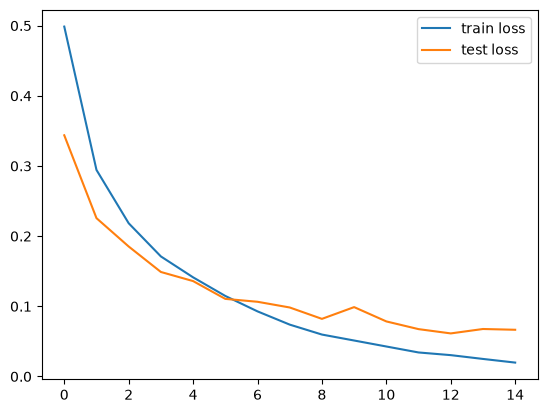

In [57]:
# Plot the train loss and test loss per iteration
plt.plot(train_losses, label='train loss')
plt.plot(test_losses, label='test loss')
plt.legend()
plt.show()

In [58]:
# Accuracy
n_correct = 0.
n_total = 0.
for inputs, targets in train_gen():
  targets = targets.view(-1, 1).float()
  inputs, targets = inputs.to(device), targets.to(device)

  outputs = model(inputs)
  predictions = (outputs > 0)

  n_correct += (predictions == targets).sum().item()
  n_total += targets.shape[0]

train_acc = n_correct / n_total

n_correct = 0.
n_total = 0.
for inputs, targets in test_gen():
  targets = targets.view(-1, 1).float()
  inputs, targets = inputs.to(device), targets.to(device)

  outputs = model(inputs)
  predictions = (outputs > 0)

  n_correct += (predictions == targets).sum().item()
  n_total += targets.shape[0]

test_acc = n_correct / n_total
print(f"Train acc: {train_acc:.4f}, Test acc: {test_acc:.4f}")

Train acc: 0.9979, Test acc: 0.9815


In [59]:
# Collect predictions and true targets in a single pass, for the confusion matrix
p_train = []
y_train = []
for inputs, targets in train_gen():
  targets = targets.view(-1, 1).float()
  inputs, targets = inputs.to(device), targets.to(device)

  outputs = model(inputs)
  predictions = (outputs > 0)

  p_train.append(predictions.cpu().numpy().flatten())
  y_train.append(targets.cpu().numpy().flatten())

p_train = np.concatenate(p_train)
y_train = np.concatenate(y_train)

p_test = []
y_test = []
for inputs, targets in test_gen():
  targets = targets.view(-1, 1).float()
  inputs, targets = inputs.to(device), targets.to(device)

  outputs = model(inputs)
  predictions = (outputs > 0)

  p_test.append(predictions.cpu().numpy().flatten())
  y_test.append(targets.cpu().numpy().flatten())

p_test = np.concatenate(p_test)
y_test = np.concatenate(y_test)

In [60]:
train_acc = np.mean(y_train == p_train)
test_acc = np.mean(y_test == p_test)
print(f"Train acc: {train_acc:.4f}, Test acc: {test_acc:.4f}")

Train acc: 0.9979, Test acc: 0.9831


In [61]:
df[df['labels'] == 'spam'].size / df.size

0.13406317300789664

In [62]:
# Plot confusion matrix
from sklearn.metrics import confusion_matrix
import itertools

def plot_confusion_matrix(cm, classes,
                          normalize=False,
                          title='Confusion matrix',
                          cmap=plt.cm.Blues):
  """
  This function prints and plots the confusion matrix.
  Normalization can be applied by setting `normalize=True`.
  """
  if normalize:
      cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
      print("Normalized confusion matrix")
  else:
      print('Confusion matrix, without normalization')

  print(cm)

  plt.imshow(cm, interpolation='nearest', cmap=cmap)
  plt.title(title)
  plt.colorbar()
  tick_marks = np.arange(len(classes))
  plt.xticks(tick_marks, classes, rotation=45)
  plt.yticks(tick_marks, classes)

  fmt = '.2f' if normalize else 'd'
  thresh = cm.max() / 2.
  for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
      plt.text(j, i, format(cm[i, j], fmt),
               horizontalalignment="center",
               color="white" if cm[i, j] > thresh else "black")

  plt.tight_layout()
  plt.ylabel('True label')
  plt.xlabel('Predicted label')
  plt.show()

Confusion matrix, without normalization
[[1593    7]
 [  24  215]]


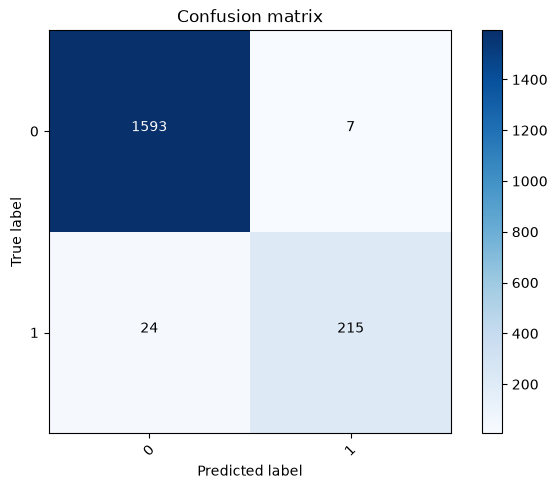

In [63]:
cm = confusion_matrix(y_test, p_test)
plot_confusion_matrix(cm, [0, 1])

Confusion matrix, without normalization
[[3225    0]
 [   8  500]]


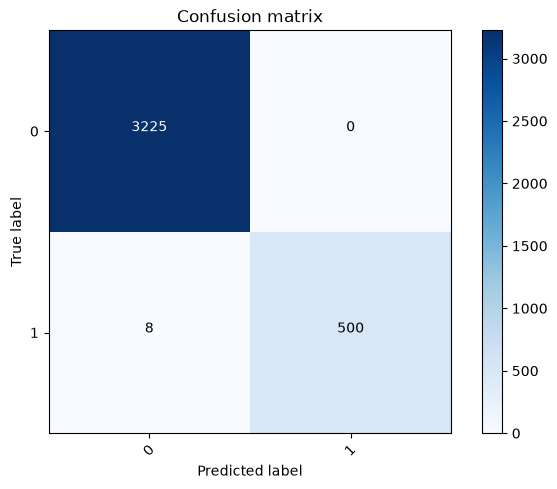

In [64]:
cm = confusion_matrix(y_train, p_train)
plot_confusion_matrix(cm, [0, 1])

### Make predictions

In [65]:
# get some random test data
df[df.labels == 'spam'].sample(3)

,labels,data,b_labels
802,spam,FREE for 1st week! No1 Nokia tone 4 ur mobile ...,1
2943,spam,We currently have a message awaiting your coll...,1
4843,spam,YOU HAVE WON! As a valued Vodafone customer ou...,1


**Note:** The original screenshots build `sample_test.csv` and load it back through torchtext's legacy `ttd.TabularDataset` / `ttd.Iterator` (`TEXT.preprocess` / `TEXT.numericalize`) to tokenize and numericalize new sentences. This notebook never used torchtext's `Field` API in the first place (see the RNN construction cells above) -- it built its own `word2idx` dictionary with plain `str.lower().split()` tokenization -- so the cells below reproduce the same "predict on a brand-new sentence" goal using that same tokenizer/vocab instead, which is both simpler and avoids torchtext's legacy API entirely (removed in torchtext >= 0.12, and its compiled extension is often broken against newer PyTorch builds -- see notebook 16 for details)."

In [66]:
def sentence_to_tensor(sentence):
  tokens = sentence.lower().split()
  # skip unknown words, same convention used for the test set above
  sentence_as_int = [word2idx[token] for token in tokens if token in word2idx]
  return torch.tensor(sentence_as_int, dtype=torch.long).view(1, -1)

single_sentence = 'Our dating service has been asked 2 contact U by someone shy! CALL 0905'
sentence_to_tensor(single_sentence)

tensor([[  59, 2764, 1175,   39,  543, 1441,   81,   82,   84,  654,  836,   91]])

In [67]:
sent_idx = sentence_to_tensor(single_sentence)
with torch.no_grad():
  logit = model(sent_idx.to(device))
logit

tensor([[3.9080]], device='mps:0')

In [68]:
# pick any random text, or make up your own.
# samp = df_test['data'].sample()
# print(samp)
text = df_test.iloc[1024]['data']
text

"I'll reach in ard 20 mins ok..."

In [69]:
# convert the text to a sequence of ints
tokens = text.lower().split()
text_int = [word2idx[token] for token in tokens if token in word2idx]

In [70]:
# make a torch tensor
text_tensor = torch.from_numpy(
    np.array([text_int])
)
text_tensor

tensor([[1341,  123,   57,  293, 1809,  779,  427]])

In [71]:
with torch.no_grad():
  out = model(text_tensor.to(device))

In [72]:
out

tensor([[-1.9845]], device='mps:0')